In [61]:
# pandas is used for loading, cleaning, merging and analysing data
import pandas as pd

# numpy is used for numerical operations
import numpy as np

# matplotlib is used for creating graphs
import matplotlib.pyplot as plt

# seaborn is used to make statistical graphs more visually appealing
import seaborn as sns

# statsmodels is used for regression modelling
import statsmodels.api as sm


In [67]:

# Load the World Happiness Report dataset
# This dataset contains happiness score and different explanatory factors
happiness_df = pd.read_csv("/Users/nico/Desktop/World Happiness Report.csv")

# Load the World Bank income group dataset
# The useful sheet is called "List of economies"
income_df = pd.read_excel(
    "/Users/nico/Desktop//CLASS_2025_10_07.xlsx",
    sheet_name="List of economies"
)


In [5]:
# Display the first few rows of the happiness dataset
happiness_df.head()

,Country,Happiness Rank,Happiness Score,Economy,Family,Health,Freedom,Generosity,Corruption,Dystopia,Job Satisfaction,Region
0,Norway,1,7.537,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027,94.6,Western Europe
1,Denmark,2,7.522,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707,93.5,Western Europe
2,Iceland,3,7.504,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715,94.5,Western Europe
3,Switzerland,4,7.494,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716,93.7,Western Europe
4,Finland,5,7.469,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182,91.2,Western Europe


In [7]:
# Display the first few rows of the World Bank income group dataset
income_df.head()

,Economy,Code,Region,Income group,Lending category
0,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA
1,Albania,ALB,Europe & Central Asia,Upper middle income,IBRD
2,Algeria,DZA,"Middle East, North Africa, Afghanistan & Pakistan",Upper middle income,IBRD
3,American Samoa,ASM,East Asia & Pacific,High income,NaN
4,Andorra,AND,Europe & Central Asia,High income,NaN


In [9]:
# Check the column names in the happiness dataset
print(happiness_df.columns)

Index(['Country', 'Happiness Rank', 'Happiness Score', 'Economy', 'Family',
       'Health', 'Freedom', 'Generosity', 'Corruption', 'Dystopia',
       'Job Satisfaction', 'Region'],
      dtype='object')


In [11]:
# Check the column names in the World Bank dataset
print(income_df.columns)

Index(['Economy', 'Code', 'Region', 'Income group', 'Lending category'], dtype='object')


In [13]:
# Check basic information about the happiness dataset
# This helps us see data types and missing values
happiness_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           153 non-null    object 
 1   Happiness Rank    153 non-null    int64  
 2   Happiness Score   153 non-null    float64
 3   Economy           153 non-null    float64
 4   Family            153 non-null    float64
 5   Health            153 non-null    float64
 6   Freedom           153 non-null    float64
 7   Generosity        153 non-null    float64
 8   Corruption        153 non-null    float64
 9   Dystopia          153 non-null    float64
 10  Job Satisfaction  151 non-null    float64
 11  Region            153 non-null    object 
dtypes: float64(9), int64(1), object(2)
memory usage: 14.5+ KB


In [15]:
# Keep only the columns needed from the World Happiness Report
happiness_clean = happiness_df[
    [
        "Country",
        "Happiness Score",
        "Economy",
        "Family",
        "Health",
        "Freedom",
        "Generosity",
        "Corruption",
        "Job Satisfaction",
        "Region"
    ]
].copy()

# Keep only useful columns from the World Bank dataset
income_clean = income_df[
    [
        "Economy",
        "Code",
        "Region",
        "Income group"
    ]
].copy()

# Rename the World Bank region column so it does not conflict with the happiness region column
income_clean = income_clean.rename(
    columns={
        "Region": "World Bank Region"
    }
)

# Display cleaned happiness data
happiness_clean.head()

,Country,Happiness Score,Economy,Family,Health,Freedom,Generosity,Corruption,Job Satisfaction,Region
0,Norway,7.537,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,94.6,Western Europe
1,Denmark,7.522,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,93.5,Western Europe
2,Iceland,7.504,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,94.5,Western Europe
3,Switzerland,7.494,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,93.7,Western Europe
4,Finland,7.469,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,91.2,Western Europe


In [17]:
# Display cleaned World Bank income group data
income_clean.head()

,Economy,Code,World Bank Region,Income group
0,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Low income
1,Albania,ALB,Europe & Central Asia,Upper middle income
2,Algeria,DZA,"Middle East, North Africa, Afghanistan & Pakistan",Upper middle income
3,American Samoa,ASM,East Asia & Pacific,High income
4,Andorra,AND,Europe & Central Asia,High income


In [19]:
# Some country names are written differently in the two datasets.
# For example, the happiness dataset may use "South Korea",
# while the World Bank dataset uses "Korea, Rep."
# This dictionary manually fixes common mismatches.

name_corrections = {
    "Czech Republic": "Czechia",
    "Slovakia": "Slovak Republic",
    "Russia": "Russian Federation",
    "South Korea": "Korea, Rep.",
    "North Korea": "Korea, Dem. People's Rep.",
    "Hong Kong S.A.R., China": "Hong Kong SAR, China",
    "Macedonia": "North Macedonia",
    "Kyrgyzstan": "Kyrgyz Republic",
    "Palestinian Territories": "West Bank and Gaza",
    "Egypt": "Egypt, Arab Rep.",
    "Iran": "Iran, Islamic Rep.",
    "Congo (Brazzaville)": "Congo, Rep.",
    "Congo (Kinshasa)": "Congo, Dem. Rep.",
    "Yemen": "Yemen, Rep.",
    "Syria": "Syrian Arab Republic",
    "Turkey": "Türkiye",
    "Somalia": "Somalia, Fed. Rep.",
    "Ivory Coast": "Côte d’Ivoire",
    "Venezuela": "Venezuela, RB"
}

# Create a new country column for merging
# This keeps the original country name unchanged
happiness_clean["Country_merge"] = happiness_clean["Country"].replace(name_corrections)

# Check the result
happiness_clean[["Country", "Country_merge"]].head()

,Country,Country_merge
0,Norway,Norway
1,Denmark,Denmark
2,Iceland,Iceland
3,Switzerland,Switzerland
4,Finland,Finland


In [21]:
# Merge the two datasets using the cleaned country names
merged_df = happiness_clean.merge(
    income_clean,
    left_on="Country_merge",
    right_on="Economy",
    how="left"
)

# Display the merged dataset
merged_df.head()

,Country,Happiness Score,Economy_x,Family,Health,Freedom,Generosity,Corruption,Job Satisfaction,Region,Country_merge,Economy_y,Code,World Bank Region,Income group
0,Norway,7.537,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,94.6,Western Europe,Norway,Norway,NOR,Europe & Central Asia,High income
1,Denmark,7.522,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,93.5,Western Europe,Denmark,Denmark,DNK,Europe & Central Asia,High income
2,Iceland,7.504,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,94.5,Western Europe,Iceland,Iceland,ISL,Europe & Central Asia,High income
3,Switzerland,7.494,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,93.7,Western Europe,Switzerland,Switzerland,CHE,Europe & Central Asia,High income
4,Finland,7.469,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,91.2,Western Europe,Finland,Finland,FIN,Europe & Central Asia,High income


In [23]:
# Countries with missing income group did not match properly
unmatched = merged_df[merged_df["Income group"].isna()][["Country", "Country_merge"]]

# Display unmatched countries
unmatched

,Country,Country_merge
59,North Cyprus,North Cyprus
80,Venezuela,"Venezuela, RB"
116,Ethiopia,Ethiopia


In [25]:
# Some economies may have missing income group in the World Bank file itself.
# We check how many countries are missing income group.
print("Number of countries without income group:", merged_df["Income group"].isna().sum())

Number of countries without income group: 3


In [27]:
# Count missing values in each column
merged_df.isna().sum()

Country              0
Happiness Score      0
Economy_x            0
Family               0
Health               0
Freedom              0
Generosity           0
Corruption           0
Job Satisfaction     2
Region               0
Country_merge        0
Economy_y            1
Code                 1
World Bank Region    1
Income group         3
dtype: int64

In [29]:
# Rename columns after merging to make them clearer
merged_df = merged_df.rename(
    columns={
        "Economy_x": "Economy",
        "Economy_y": "World Bank Country"
    }
)

# Check column names again
print(merged_df.columns)

Index(['Country', 'Happiness Score', 'Economy', 'Family', 'Health', 'Freedom',
       'Generosity', 'Corruption', 'Job Satisfaction', 'Region',
       'Country_merge', 'World Bank Country', 'Code', 'World Bank Region',
       'Income group'],
      dtype='object')


In [31]:
# Drop rows with missing values in the variables used for analysis
# This avoids errors in regression models and plots
analysis_df = merged_df.dropna(
    subset=[
        "Happiness Score",
        "Economy",
        "Family",
        "Health",
        "Freedom",
        "Generosity",
        "Corruption",
        "Income group"
    ]
).copy()

# Check final analysis dataset
analysis_df.shape

(150, 15)

In [33]:
# Summary statistics help us understand the scale and spread of each variable
analysis_df[
    [
        "Happiness Score",
        "Economy",
        "Family",
        "Health",
        "Freedom",
        "Generosity",
        "Corruption"
    ]
].describe()

,Happiness Score,Economy,Family,Health,Freedom,Generosity,Corruption
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.352800,0.983318,1.187148,0.549085,0.409765,0.245933,0.123074
std,1.143392,0.421631,0.289440,0.238407,0.150727,0.134809,0.102952
min,2.693000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.501250,0.661444,1.042312,0.367188,0.302209,0.153590,0.056843
50%,5.286000,1.059638,1.252872,0.605316,0.438880,0.231225,0.089565
75%,6.103250,1.315027,1.415360,0.717596,0.519885,0.324529,0.150105
max,7.537000,1.870766,1.610574,0.949492,0.658249,0.838075,0.464308


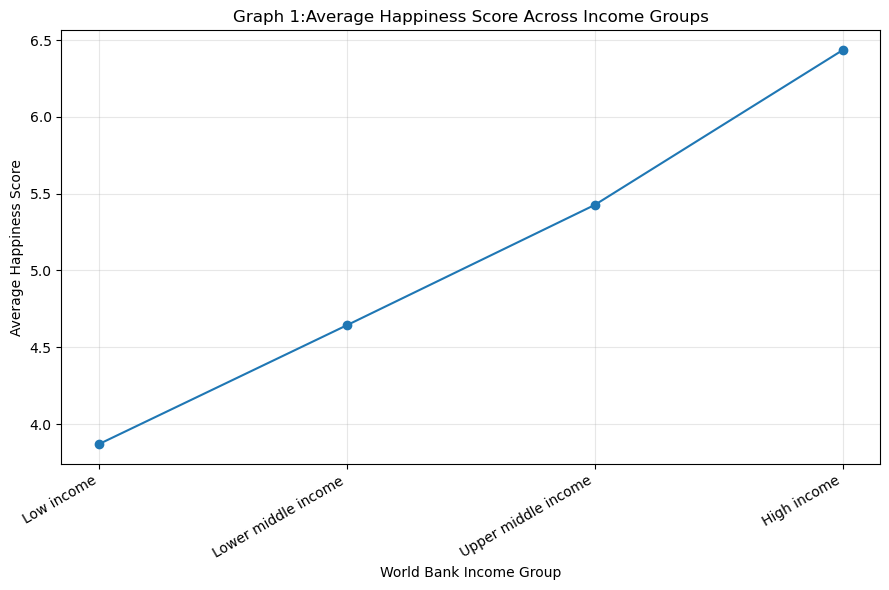

In [43]:

# Graph 1: Line graph of average happiness by income group

# Define the correct order of income groups
# This makes the line go from low income to high income
income_order = [
    "Low income",
    "Lower middle income",
    "Upper middle income",
    "High income"
]

# Calculate the average happiness score for each income group
line_data = analysis_df.groupby("Income group")["Happiness Score"].mean()

# Reorder the income groups in a logical economic order
line_data = line_data.reindex(income_order)

# Set graph size
plt.figure(figsize=(9, 6))

# Create line graph with markers
plt.plot(
    line_data.index,
    line_data.values,
    marker="o"
)

# Add title and axis labels
plt.title("Graph 1:Average Happiness Score Across Income Groups")
plt.xlabel("World Bank Income Group")
plt.ylabel("Average Happiness Score")

# Rotate x-axis labels to make them easier to read
plt.xticks(rotation=30, ha="right")

# Add grid lines to make comparison easier
plt.grid(True, alpha=0.3)

# Improve layout
plt.tight_layout()

# Show graph
plt.show()

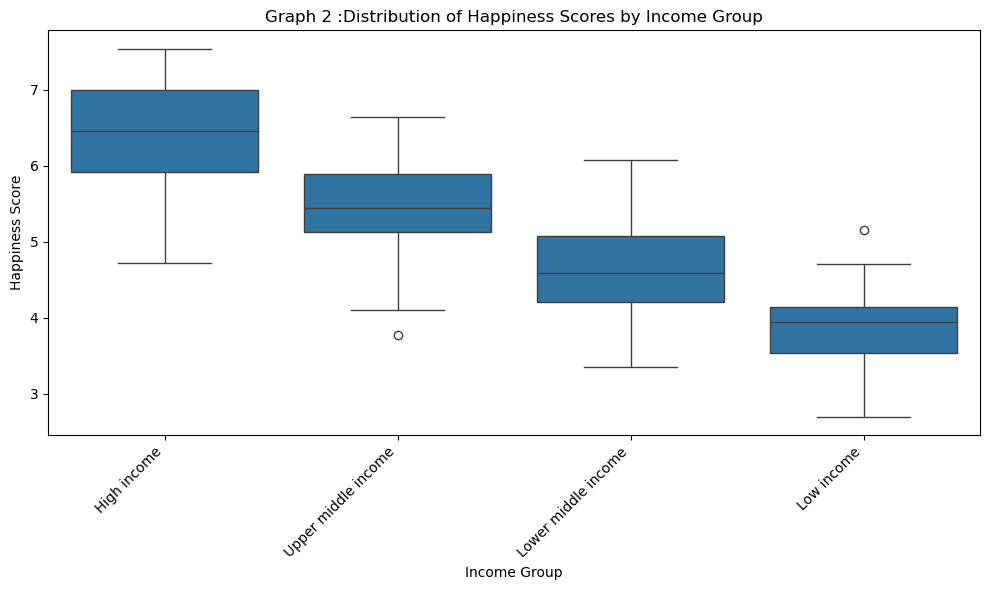

In [47]:

# Graph 2: Box plot of happiness score by income group

# Set graph size
plt.figure(figsize=(10, 6))

# Create box plot
sns.boxplot(
    data=analysis_df,
    x="Income group",
    y="Happiness Score"
)

# Add title and labels
plt.title("Graph 2 :Distribution of Happiness Scores by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Happiness Score")

# Rotate x-axis labels
plt.xticks(rotation=45, ha="right")

# Improve layout
plt.tight_layout()

# Show graph
plt.show()

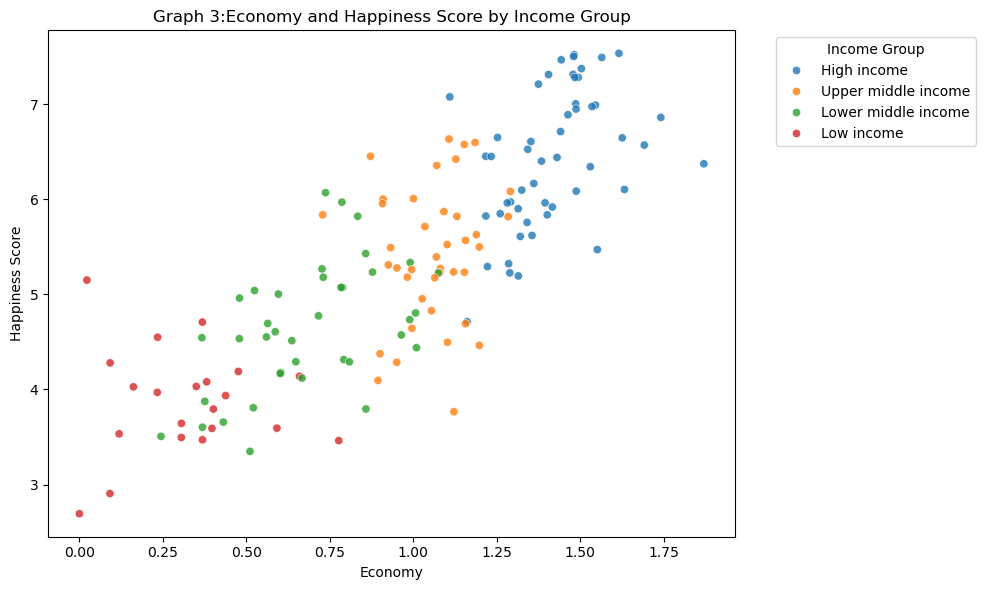

In [49]:
# Graph 3: Scatter plot coloured by income group
# ============================================================

# Set graph size
plt.figure(figsize=(10, 6))

# Create scatter plot with different colours for each income group
sns.scatterplot(
    data=analysis_df,
    x="Economy",
    y="Happiness Score",
    hue="Income group",
    alpha=0.8
)

# Add title and labels
plt.title("Graph 3:Economy and Happiness Score by Income Group")
plt.xlabel("Economy")
plt.ylabel("Happiness Score")

# Move legend outside the plot
plt.legend(title="Income Group", bbox_to_anchor=(1.05, 1), loc="upper left")

# Improve layout
plt.tight_layout()

# Show graph
plt.show()

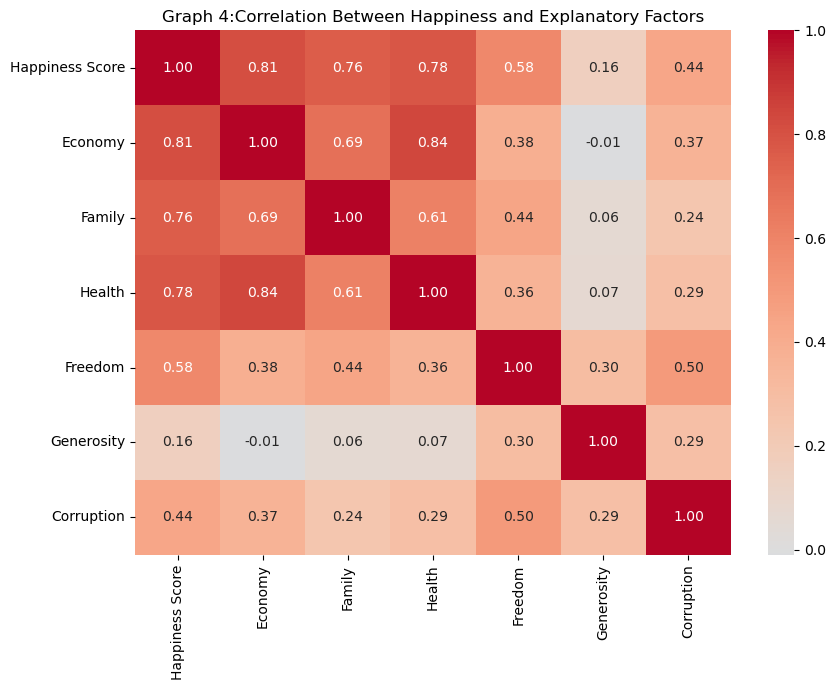

In [53]:
# Graph 4: Correlation heatmap

# Select numerical variables for correlation analysis
corr_vars = analysis_df[
    [
        "Happiness Score",
        "Economy",
        "Family",
        "Health",
        "Freedom",
        "Generosity",
        "Corruption"
    ]
]

# Calculate correlation matrix
corr_matrix = corr_vars.corr()

# Set graph size
plt.figure(figsize=(9, 7))

# Create heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

# Add title
plt.title("Graph 4:Correlation Between Happiness and Explanatory Factors")

# Improve layout
plt.tight_layout()

# Show graph
plt.show()

In [69]:
#  Regression model

# Define the dependent variable
# This is the outcome we want to explain
y = analysis_df["Happiness Score"]

# Define independent variables
# These are the factors that may explain happiness
X = analysis_df[
    [
        "Economy",
        "Family",
        "Health",
        "Freedom",
        "Generosity",
        "Corruption"
    ]
]

# Add a constant term to the regression model
# This is needed for statsmodels OLS regression
X = sm.add_constant(X)

# Run OLS regression
model = sm.OLS(y, X).fit()

# Print regression results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Happiness Score   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     103.9
Date:                Thu, 14 May 2026   Prob (F-statistic):           1.29e-49
Time:                        08:20:20   Log-Likelihood:                -106.51
No. Observations:                 150   AIC:                             227.0
Df Residuals:                     143   BIC:                             248.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.7263      0.190      9.083      0.0

In [57]:
# Standardised regression coefficient plot

# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Define dependent variable
y = analysis_df["Happiness Score"]

# Define explanatory variables
X = analysis_df[
    [
        "Economy",
        "Family",
        "Health",
        "Freedom",
        "Generosity",
        "Corruption"
    ]
]

# Standardise the explanatory variables
# This puts all variables on the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert the scaled data back into a dataframe
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

# Add a constant term for the regression
X_scaled = sm.add_constant(X_scaled)

# Run OLS regression using standardised variables
standardised_model = sm.OLS(y, X_scaled).fit()

# Print regression results
print(standardised_model.summary())

                            OLS Regression Results                            
Dep. Variable:        Happiness Score   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     103.9
Date:                Thu, 14 May 2026   Prob (F-statistic):           1.29e-49
Time:                        07:33:46   Log-Likelihood:                -106.51
No. Observations:                 150   AIC:                             227.0
Df Residuals:                     143   BIC:                             248.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.3528      0.041    130.050      0.0

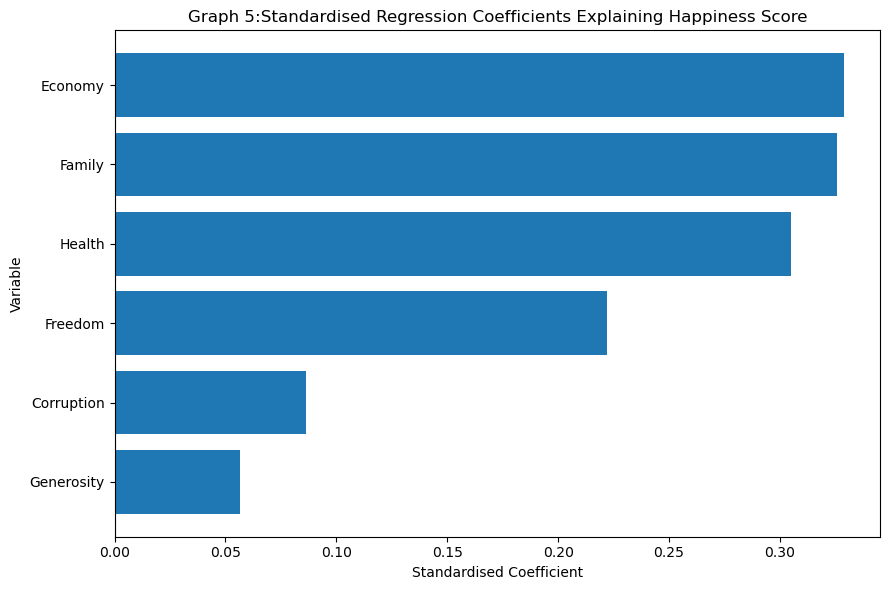

In [71]:
# Graph 5: Standardised regression coefficients


# Extract coefficients, excluding the constant
coefficients = standardised_model.params.drop("const")

# Create dataframe for plotting
coef_df = pd.DataFrame({
    "Variable": coefficients.index,
    "Coefficient": coefficients.values
})

# Sort by coefficient size
coef_df = coef_df.sort_values("Coefficient")

# Set graph size
plt.figure(figsize=(9, 6))

# Create horizontal bar chart
plt.barh(coef_df["Variable"], coef_df["Coefficient"])

# Add vertical line at zero
plt.axvline(0, linestyle="--")

# Add title and labels
plt.title("Graph 5:Standardised Regression Coefficients Explaining Happiness Score")
plt.xlabel("Standardised Coefficient")
plt.ylabel("Variable")

# Improve layout
plt.tight_layout()

# Show graph
plt.show()